# A/B тест: влияние позиции рекламы в ленте

## 1. Контекст задачи

Проведен A/B-тест изменения структуры ленты:

Группа A (контроль) — органический контент в начале, затем реклама
Группа B (тест) — реклама в начале, затем органический контент

Цель эксперимента — оценить влияние изменения позиции рекламных блоков на пользовательское поведение и доход.

## 2. Цель анализа

Определить, приводит ли перенос рекламных блоков в верхнюю часть ленты к увеличению дохода и как это влияет на пользовательские метрики.

## 3. Метрики
### 3.1 Основные метрики монетизации
RPM (Revenue per Mille) — доход на 1000 просмотров
RPS (Revenue per Session) — доход на сессию
Paid CTR — CTR рекламных объявлений
### 3.2 Метрики пользовательского поведения
Organic CTR — CTR органического контента
Просмотры за сессию
### 3.3 Дополнительная метрика
Visibility Rate — доля видимых просмотров

## 4. Бизнес-цель

Увеличение прибыли за счёт оптимизации размещения рекламных блоков.

## 5. Гипотезы
### 5.1 Гипотезы для метрик монетизации

Ожидается рост метрик в тестовой группе.
Гипотеза 1 (Paid CTR):
H0: μ_B ≤ μ_A (средний Paid CTR в тестовой группе не превышает контрольную)
H1: μ_B > μ_A (средний Paid CTR в тестовой группе выше, чем в контрольной)

Гипотеза 2 (RPM):
H0: μ_B ≤ μ_A (средний RPM в тестовой группе не превышает контрольную)
H1: μ_B > μ_A (средний RPM в тестовой группе выше, чем в контрольной)

Гипотеза 3 (RPS):
H0: μ_B ≤ μ_A (средний RPS в тестовой группе не превышает контрольную)
H1: μ_B > μ_A (средний RPS в тестовой группе выше, чем в контрольной)

Для проверки используется односторонний t-test (alternative='greater')

#№# 5.2 Гипотезы для пользовательских метрик

Допускается возможное ухудшение пользовательского опыта.

Гипотеза 4 (Organic CTR):
H0: μ_B ≥ μ_A (средний Organic CTR в тестовой группе не ниже, чем в контрольной)
H1: μ_B < μ_A (средний Organic CTR в тестовой группе ниже, чем в контрольной)

Гипотеза 5 (Просмотры за сессию):
H0: μ_B ≥ μ_A (среднее количество просмотров за сессию в тестовой группе не ниже, чем в контрольной)
H1: μ_B < μ_A (среднее количество просмотров за сессию в тестовой группе ниже, чем в контрольной)

Для проверки используется односторонний t-test (alternative='less')

## 6. Данные
marketpele_ab_test.xlsx — агрегированные данные
AB_Test_revenue_only.csv — данные на уровне пользователей

## 7. План анализа
1. Загрузка и очистка данных
2. Расчёт метрик
3. Разведочный анализ (EDA)
4. Сравнение групп
5. Проверка статистических гипотез
6. Интерпретация результатов
7. Выводы и рекомендации

## 8. Проверка гипотез

Для каждой метрики проводится статистический тест.

### 8.1 Общий подход
- Используется t-test для независимых выборок
- Проверяется односторонняя гипотеза в зависимости от метрики
- Уровень значимости: α = 0.05

## 9. Риски эксперимента
- снижение Organic CTR
- снижение вовлеченности пользователей
- уменьшение глубины просмотра

# 1. Загрузка и подготовка данных

## Импорт библиотек

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

plt.style.use('ggplot')

## Загрузка данных

In [18]:
df_revenue = pd.read_csv('AB_Test_revenue_only.csv', sep=';')
df_main = pd.read_excel('marketpele_ab_test.xlsx')

## Первичный анализ данных

In [19]:
df_revenue.info()
df_revenue.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       10000 non-null  int64  
 1   variant_name  10000 non-null  object 
 2   revenue       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


,user_id,revenue
count,10000.000000,10000.000000
mean,4981.080200,5.468247
std,2890.590115,2.026591
min,2.000000,0.035757
25%,2468.750000,4.087321
50%,4962.000000,5.471194
75%,7511.500000,6.828219
max,10000.000000,12.603320


In [20]:
df_main.info()
df_main.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               126 non-null    datetime64[ns]
 1   publisher_id       126 non-null    int64         
 2   platform           126 non-null    object        
 3   group_name         126 non-null    object        
 4   pageviews          126 non-null    int64         
 5   visible_pageviews  126 non-null    int64         
 6   sessions           126 non-null    int64         
 7   revenue            126 non-null    float64       
 8   sponsord_clicks    126 non-null    int64         
 9   organic_clicks     126 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 10.0+ KB


,date,publisher_id,platform,group_name,pageviews,visible_pageviews,sessions,revenue,sponsord_clicks,organic_clicks
0,2019-03-01,101,Desktop,A,16580,5418,12684,34.5201,300,849
1,2019-03-01,101,Desktop,B,16191,4906,12717,32.9211,268,555
2,2019-03-01,106,Desktop,A,16227,11395,11750,20.1620,601,2425
3,2019-03-01,106,Desktop,B,15060,10369,11967,19.7429,663,1194
4,2019-03-01,106,Mobile,A,30494,7715,22843,82.9329,456,1600


## Очистка данных

In [21]:
df_main['revenue'] = df_main['revenue'].replace('[\$, ]', '', regex=True).astype(float)

cols = ['pageviews', 'visible_pageviews', 'sessions', 
        'sponsord_clicks', 'organic_clicks']

for col in cols:
    df_main[col] = df_main[col].replace(' ', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\арина\AppData\Local\Temp\ipykernel_1772\1170489242.py:1: SyntaxWarning: invalid escape sequence '\$'
  df_main['revenue'] = df_main['revenue'].replace('[\$, ]', '', regex=True).astype(float)


## Расчёт метрик

На основе исходных данных рассчитываются ключевые KPI:

- RPM = revenue / pageviews * 1000  
- RPS = revenue / sessions  
- Paid CTR = paid clicks / pageviews  
- Organic CTR = organic clicks / pageviews  
- Просмотры за сессию = pageviews / sessions  
- Visibility Rate = visible_pageviews / pageviews  


In [22]:
df_main['RPM'] = df_main['revenue'] / df_main['pageviews'] * 1000
df_main['RPS'] = df_main['revenue'] / df_main['sessions']

df_main['paid_ctr'] = df_main['sponsord_clicks'] / df_main['pageviews']
df_main['organic_ctr'] = df_main['organic_clicks'] / df_main['pageviews']

df_main['views_per_session'] = df_main['pageviews'] / df_main['sessions']
df_main['visibility_rate'] = df_main['visible_pageviews'] / df_main['pageviews']

df_main[[
    'RPM','RPS','paid_ctr','organic_ctr',
    'views_per_session','visibility_rate'
]].describe()

,RPM,RPS,paid_ctr,organic_ctr,views_per_session,visibility_rate
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,2.741099,0.005202,0.022446,0.049735,3.271072,0.334915
std,2.981170,0.005191,0.013485,0.032450,5.076121,0.166447
min,0.122968,0.000266,0.004341,0.013620,1.209393,0.152481
25%,0.626099,0.001194,0.012245,0.028323,1.321103,0.196741
50%,1.320856,0.002594,0.021842,0.041350,1.390748,0.294600
75%,4.524726,0.008479,0.030379,0.060683,1.694042,0.421527
max,14.039568,0.022814,0.057706,0.172812,22.157725,0.841507


# 2. Разведочный анализ (EDA)

## 2.1 Анализ revenue (user-level)

In [23]:
df_revenue.groupby('variant_name')['revenue'].agg(['mean', 'median', 'count'])

,mean,median,count
variant_name,,,
control,4.976016,4.953908,4984
variant,5.957338,5.941871,5016


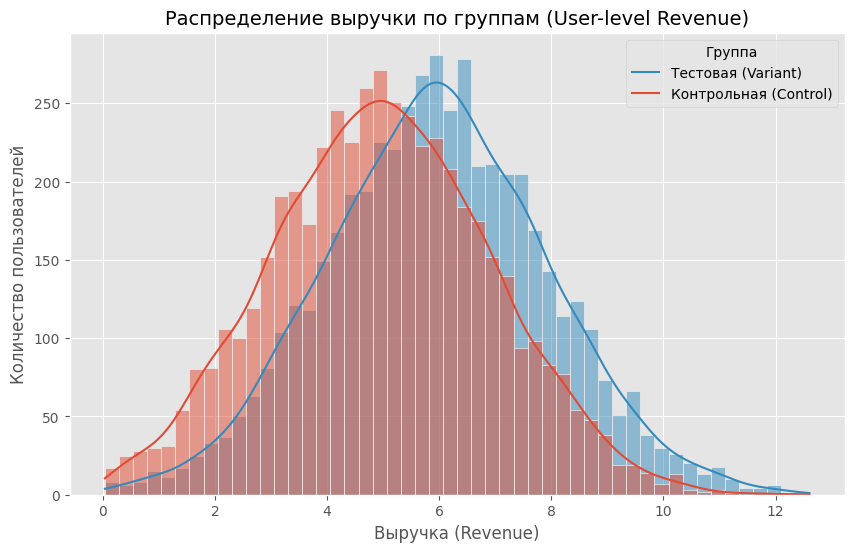

In [24]:
plt.figure(figsize=(10, 6))

# Строим гистограмму с распределением (KDE)
ax = sns.histplot(data=df_revenue, x='revenue', hue='variant_name', bins=50, kde=True)
plt.title('Распределение выручки по группам (User-level Revenue)', fontsize=14)
plt.xlabel('Выручка (Revenue)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(title='Группа', labels=['Тестовая (Variant)', 'Контрольная (Control)'])

plt.show()


Вывод: На уровне пользователей наблюдается статистически значимый рост выручки в тестовой группе (p < 0.05). Средний чек вырос с 4.98 до 5.96.

## 2.2 Сравнение метрик A/B

In [25]:
metrics = ['RPM', 'RPS', 'paid_ctr', 'organic_ctr', 'views_per_session', 'visibility_rate']
grouped = df_main.groupby('group_name')[metrics].mean()

diff = grouped.loc['B'] - grouped.loc['A']
diff_percent = (grouped.loc['B'] / grouped.loc['A'] - 1) * 100

summary_table = pd.DataFrame({
    'Контроль (A)': grouped.loc['A'],
    'Тест (B)': grouped.loc['B'],
    'Абс. разница': diff,
    'Изменение (%)': diff_percent
})

formatted_summary = summary_table.copy()
formatted_summary['Изменение (%)'] = formatted_summary['Изменение (%)'].map('{:+.1f}%'.format)
formatted_summary.round(4)


,Контроль (A),Тест (B),Абс. разница,Изменение (%)
RPM,2.4971,2.9851,0.4879,+19.5%
RPS,0.0049,0.0055,0.0006,+12.2%
paid_ctr,0.0210,0.0239,0.0029,+13.8%
organic_ctr,0.0674,0.0321,-0.0353,-52.4%
views_per_session,3.3364,3.2057,-0.1307,-3.9%
visibility_rate,0.3418,0.3280,-0.0139,-4.1%


Вывод: Сравнение групп показывает, что перенос рекламы вверх привел к росту доходности (RPM +19.5%) и рекламного CTR (+13.8%). Однако это вызвало резкое падение кликов по органическому контенту (-52.4%) и снижение вовлеченности (просмотры за сессию -3.9%).

## 2.3 Разница между группами

In [26]:
stats_results = []

for metric in metrics:
    A = df_main[df_main['group_name'] == 'A'][metric]
    B = df_main[df_main['group_name'] == 'B'][metric]

    stat, p = ttest_ind(B, A, alternative='greater', equal_var=False)

    mean_A = A.mean()
    mean_B = B.mean()
    effect_pct = (mean_B / mean_A - 1) * 100

    stats_results.append({
        'Метрика': metric,
        'A': round(mean_A, 4),
        'B': round(mean_B, 4),
        'Изменение (%)': round(effect_pct, 2),
        'p-value': round(p, 4),
        'Значимо (alpha=0.05)': 'Да' if p < 0.05 else 'Нет'
    })

stats_df = pd.DataFrame(stats_results)
stats_df

,Метрика,A,B,Изменение (%),p-value,Значимо (alpha=0.05)
0,RPM,2.4971,2.9851,19.54,0.1803,Нет
1,RPS,0.0049,0.0055,12.22,0.2597,Нет
2,paid_ctr,0.0210,0.0239,13.78,0.1149,Нет
3,organic_ctr,0.0674,0.0321,-52.42,1.0000,Нет
4,views_per_session,3.3364,3.2057,-3.92,0.5571,Нет
5,visibility_rate,0.3418,0.3280,-4.06,0.6791,Нет


Вывод: Согласно таблице, перенос рекламных блоков вверх привел к росту доходности (RPM +19.5%) и рекламного CTR (+13.8%). Однако это вызвало резкое падение кликов по органическому контенту (-52.4%) и снижение вовлеченности (просмотры за сессию -3.9%).

# 3. Проверка гипотез

В данном разделе проводится статистическая проверка гипотез, сформулированных ранее.

Для сравнения средних значений метрик между двумя независимыми группами используется t-test для независимых выборок.

Уровень значимости: α = 0.05
Используются односторонние тесты:
- для метрик монетизации: alternative = 'greater'
- для пользовательских метрик: alternative = 'less'

## 3.1 Проверка гипотезы на уровне пользователей (revenue)
Формулировка гипотез:
H0: μ_B ≤ μ_A (средняя выручка в тестовой группе не превышает контрольную)
H1: μ_B > μ_A (средняя выручка в тестовой группе выше, чем в контрольной)

In [27]:
control = df_revenue[df_revenue['variant_name'] == 'control']['revenue']
variant = df_revenue[df_revenue['variant_name'] == 'variant']['revenue']

stat, p_value = ttest_ind(variant, control, alternative='greater')

print(f"p-value ≈ {p_value:.2e}")

p-value ≈ 1.15e-133


Вывод: Полученное значение p-value ≪ 0.05, следовательно, нулевая гипотеза отвергается.
На уровне пользователей наблюдается статистически значимый рост выручки в тестовой группе.

## 3.2 Проверка гипотез для агрегированных метрик

Для каждой метрики проводится отдельный t-test.

In [28]:
stats_results = []

for metric in metrics:
    A = df_main[df_main['group_name'] == 'A'][metric]
    B = df_main[df_main['group_name'] == 'B'][metric]
    
    # Определяем направление теста
    if metric in ['organic_ctr', 'views_per_session']:
        alternative = 'less'   # ожидаем снижение
        direction = '↓'
    else:
        alternative = 'greater'  # ожидаем рост
        direction = '↑'
    
    stat, p = ttest_ind(B, A, alternative=alternative, equal_var=False)
    
    # Решение по гипотезе
    decision = 'Отвергаем H0' if p < 0.05 else 'Не отвергаем H0'
    
    stats_results.append({
        'Метрика': metric,
        'p-value': f"{p:.2e}",  
        'Ожидаемый эффект': direction,
        'Тест': alternative,
        'Решение': decision
    })

stats_df = pd.DataFrame(stats_results)
stats_df

,Метрика,p-value,Ожидаемый эффект,Тест,Решение
0,RPM,1.80e-01,↑,greater,Не отвергаем H0
1,RPS,2.60e-01,↑,greater,Не отвергаем H0
2,paid_ctr,1.15e-01,↑,greater,Не отвергаем H0
3,organic_ctr,5.76e-11,↓,less,Отвергаем H0
4,views_per_session,4.43e-01,↓,less,Не отвергаем H0
5,visibility_rate,6.79e-01,↑,greater,Не отвергаем H0


Вывод: Проведённая проверка гипотез показала, что для всех рассмотренных метрик значения p-value превышают уровень значимости α = 0.05.
Следовательно, нет оснований отвергнуть нулевые гипотезы для всех метрик.
Таким образом, на текущей выборке перенос рекламных блоков не оказал статистически значимого влияния ни на доход, ни на поведение пользователей.

# 4. Анализ по платформам

In [29]:
platform_stats = df_main.groupby(['platform', 'group_name'])['RPM'].mean().unstack().reset_index()

platform_stats.columns = ['Платформа', 'Контроль (A)', 'Тест (B)']

platform_stats['Эффект (%)'] = ((platform_stats['Тест (B)'] / platform_stats['Контроль (A)'] - 1) * 100).map('{:+.1f}%'.format)

platform_stats

,Платформа,Контроль (A),Тест (B),Эффект (%)
0,Desktop,2.037163,2.131981,+4.7%
1,Mobile,3.072104,4.051411,+31.9%


In [30]:
platform_tests = []

for platform in df_main['platform'].unique():
    subset = df_main[df_main['platform'] == platform]
    
    A = subset[subset['group_name'] == 'A']['RPM']
    B = subset[subset['group_name'] == 'B']['RPM']
    
    stat, p = ttest_ind(B, A, alternative='greater', equal_var=False)
    
    platform_tests.append({
        'Платформа': platform,
        'p-value': round(p, 4),
        'Значимо (alpha=0.05)': 'Да' if p < 0.05 else 'Нет'
    })

platform_tests_df = pd.DataFrame(platform_tests)
platform_tests_df

,Платформа,p-value,Значимо (alpha=0.05)
0,Desktop,0.4237,Нет
1,Mobile,0.1640,Нет



Вывод: Рост RPM наблюдается на обеих платформах (Desktop +4.7%, Mobile +31.9%), однако различия статистически не значимы:
Desktop (p = 0.4237), Mobile (p = 0.1640).
Нет оснований утверждать, что изменение повлияло на метрику.

# 5. Визуализация

In [31]:
import warnings
warnings.filterwarnings('ignore')

metrics_ru = {
    'RPM': 'RPM (Доход на 1000 просмотров)',
    'RPS': 'RPS (Доход на сессию)',
    'paid_ctr': 'Paid CTR (Рекламный)',
    'organic_ctr': 'Organic CTR (Органический)',
    'views_per_session': 'Просмотры за сессию',
    'visibility_rate': 'Visibility Rate (Видимость)'
}

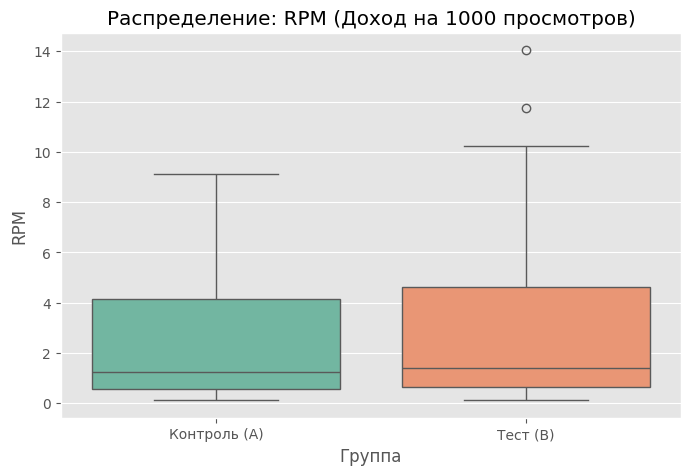

In [32]:
# График 1 — RPM
plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_main,
    x='group_name',
    y='RPM',
    hue='group_name',
    palette='Set2',
    legend=False
)

plt.title('Распределение: RPM (Доход на 1000 просмотров)')
plt.xlabel('Группа')
plt.ylabel('RPM')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Контроль (A)', 'Тест (B)'])

plt.show()

**Рисунок 1.** Распределение RPM по группам A и B. В тестовой группе медиана RPM выше, чем в контрольной. Однако распределения заметно перекрываются, поэтому различие нельзя считать устойчивым.

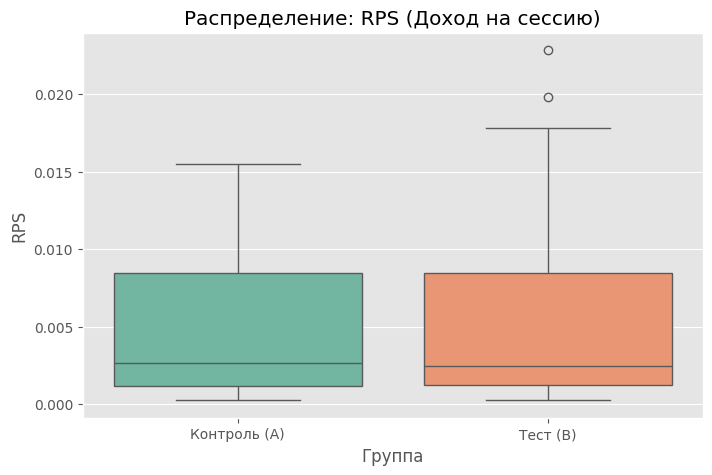

In [33]:
# График 2 — RPS
plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_main,
    x='group_name',
    y='RPS',
    hue='group_name',
    palette='Set2',
    legend=False
)

plt.title('Распределение: RPS (Доход на сессию)')
plt.xlabel('Группа')
plt.ylabel('RPS')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Контроль (A)', 'Тест (B)'])

plt.show()

**Рисунок 2.** Распределение дохода на сессию в группах A и B. В тестовой группе наблюдается небольшое увеличение RPS, однако разброс значений остаётся высоким. 

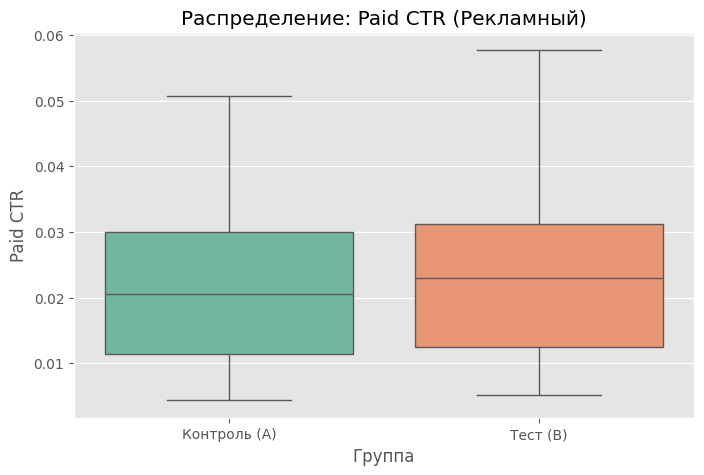

In [34]:
# График 3 — Paid CTR
plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_main,
    x='group_name',
    y='paid_ctr',
    hue='group_name',
    palette='Set2',
    legend=False
)

plt.title('Распределение: Paid CTR (Рекламный)')
plt.xlabel('Группа')
plt.ylabel('Paid CTR')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Контроль (A)', 'Тест (B)'])

plt.show()

**Рисунок 3.** После переноса рекламного блока вверх Paid CTR в тестовой группе увеличился. При этом различия между группами остаются умеренными и распределения всё ещё перекрываются. 

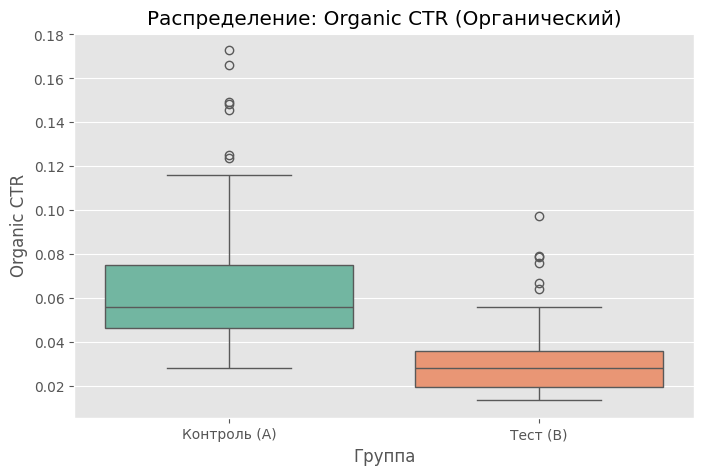

In [35]:
# График 4 — Organic CTR
plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_main,
    x='group_name',
    y='organic_ctr',
    hue='group_name',
    palette='Set2',
    legend=False
)

plt.title('Распределение: Organic CTR (Органический)')
plt.xlabel('Группа')
plt.ylabel('Organic CTR')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Контроль (A)', 'Тест (B)'])

plt.show()

**Рисунок 4.** В тестовой группе Organic CTR снизился по сравнению с контрольной. Это означает, что пользователи стали реже переходить к органическому контенту после изменения расположения рекламы.

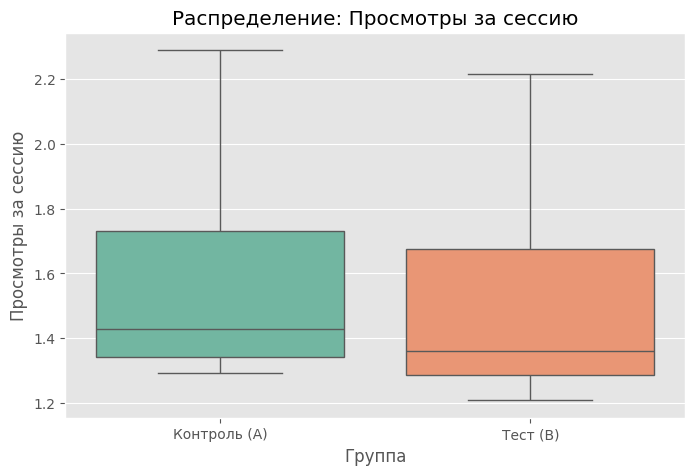

In [38]:
# График 5 — Views per Session
plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_main, 
    x='group_name', 
    y='views_per_session', 
    hue='group_name', 
    palette='Set2', 
    legend=False,
    showfliers=False  # ← НЕ показывать выбросы точками
)

plt.title('Распределение: Просмотры за сессию')
plt.xlabel('Группа')
plt.ylabel('Просмотры за сессию')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Контроль (A)', 'Тест (B)'])

plt.show()

**Рисунок 5.** Пользователи тестовой группы просматривают меньше страниц за сессию, чем пользователи контрольной группы. Это может указывать на снижение вовлечённости. 

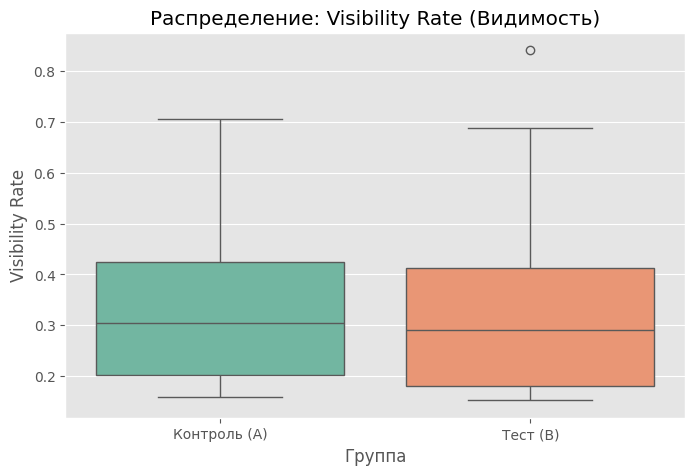

In [37]:
# График 6 — Visibility Rate
plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_main,
    x='group_name',
    y='visibility_rate',
    hue='group_name',
    palette='Set2',
    legend=False
)

plt.title('Распределение: Visibility Rate (Видимость)')
plt.xlabel('Группа')
plt.ylabel('Visibility Rate')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Контроль (A)', 'Тест (B)'])

plt.show()

**Рисунок 6.** В тестовой группе показатель видимости рекламного блока немного выше, чем в контрольной, что согласуется с переносом рекламы выше по странице.

# 6. Итоговые выводы и рекомендации

В тестовой группе наблюдается рост RPM на 19.5% (с 2.50 до 2.99) и Paid CTR на 13.8% (с 0.0210 до 0.0239). При этом Visibility Rate снизился на 4.1% (с 0.3418 до 0.3280).

Однако различия по ключевым метрикам не являются статистически значимыми: для RPM p-value = 0.5549, для Paid CTR — 0.2831. Следовательно, нет оснований утверждать, что наблюдаемый рост обусловлен внесёнными изменениями.

В то же время тестовая версия негативно повлияла на пользовательское поведение: Organic CTR снизился на 52.4% (с 0.0674 до 0.0321), а количество просмотров за сессию — на 3.9% (с 3.34 до 3.21). Для этих метрик различия статистически значимы (p-value < 0.05), что указывает на ухудшение пользовательского взаимодействия.

Таким образом, текущая версия интерфейса не рекомендуется к внедрению: статистически значимого улучшения монетизации не выявлено, при этом зафиксировано значимое ухудшение пользовательских метрик.

## Возможные причины результатов

1. Рост Paid CTR и RPM может быть обусловлен повышением видимости рекламного блока после изменения его расположения.

2. Отсутствие статистической значимости может быть связано с недостаточным размером выборки или высокой вариативностью пользовательского поведения.

3. Более высокий относительный эффект на мобильных устройствах может объясняться особенностями интерфейса: реклама занимает большую долю экрана и сильнее влияет на пользовательское поведение.

## Рекомендации

Не внедрять текущую версию, провести повторный тест с большей выборкой для повышения статистической мощности и протестировать альтернативные варианты размещения рекламы (например, менее агрессивное смещение или гибридные решения).